In [145]:
#importing the essential libraries
import torch as tch
import torch.optim as optim
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns 
import numpy as np

In [146]:
#creating the two varaibles (toy set)
X = tch.tensor([[0.,0.],
                 [0., 1.],
                 [1., 0.],
                 [1., 1.]])
y = tch.tensor([[0.],
                 [1.],
                 [1.],
                 [0.]])

In [147]:
#Converting the tensor to numpy array
X_np = X.numpy()
y_np = y.numpy()

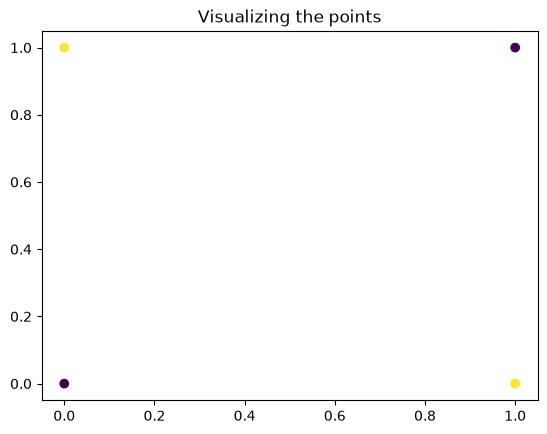

In [148]:
#Potting the scatter plot using the above two variables
plt.scatter(x=X_np[:,0], y=X_np[:, 1], c=y_np)
plt.title('Visualizing the points')
plt.show()

In [149]:
class LinearModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc = nn.Linear(2,1)

    def forward(self, x):
        return tch.sigmoid(self.fc(x))

In [150]:
model_lin = LinearModel()

In [151]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model_lin.parameters(), lr=0.01)

for epoch in range(500):
    output = model_lin(X)
    loss = criterion(output, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print(f'Prediciton linear')
print(f'{model_lin(X).round()}')

Prediciton linear
tensor([[0.],
        [0.],
        [0.],
        [0.]], grad_fn=<RoundBackward0>)


In [152]:
class XoRnn(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden = nn.Linear(2,4)
        self.relu = nn.ReLU()
        self.output = nn.Linear(4,1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        return self.sigmoid(x)

In [153]:
model_nn = XoRnn()

In [154]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model_nn.parameters(), lr=0.1)

#To check the losses
losses = []

for epoch in range(500):
    output = model_nn(X)
    loss = criterion(output, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())

print(f'Prediciton linear')
print(f'{model_nn(X).round()}')

Prediciton linear
tensor([[1.],
        [1.],
        [1.],
        [0.]], grad_fn=<RoundBackward0>)


In [155]:
def plot_DB(model, title):
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                        np.linspace(y_min, y_max, 100))
    grid = tch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype= tch.float32)

    with tch.no_grad():
        preds = model(grid)
        preds = preds.reshape(xx.shape)

    plt.contour(xx, yy, preds, cmap='RdBu', alpha=0.5)

    X_np = X.numpy()
    y_np = y.numpy()

    plt.scatter(X_np[:,0], X_np[:,1], c=y_np)
    plt.title(title)
    plt.show()

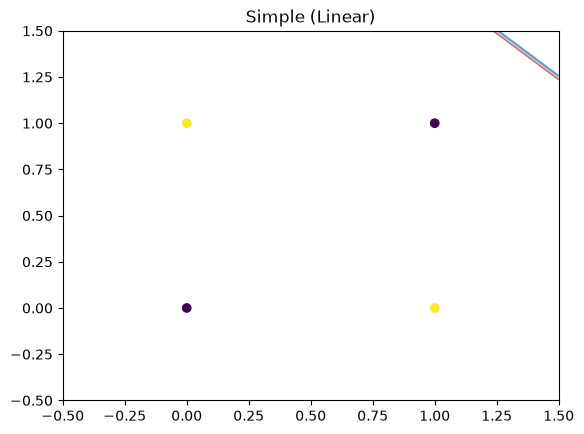

In [157]:
plot_DB(model_lin, 'Simple (Linear)')


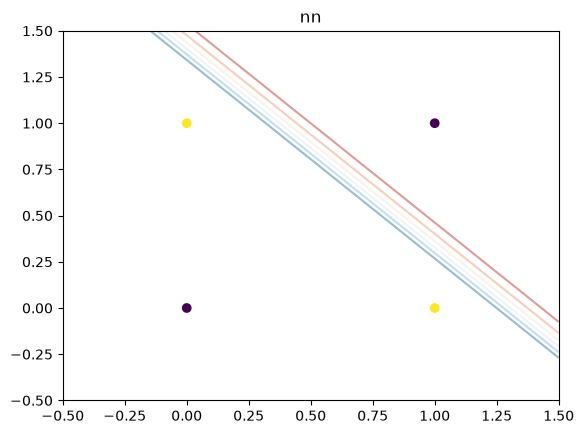

In [159]:
plot_DB(model_nn, 'nn')

In [162]:
def predective_model(model):
    #taking input from the users
    x1 = float(input('Enter the x1: '))
    x2 = float(input('Enter the x2: '))

    x = tch.tensor([x1, x2], dtype= tch.float32)

    with tch.no_grad():
        output = model(x)
        confidence = (output > 0.5).float()

    print('Overall confidence of the model: ', confidence.item())
    print('The output: ', output.item())

In [163]:
predective_model(model_nn)

Enter the x1:  1
Enter the x2:  1


Overall confidence of the model:  0.0
The output:  8.076382800936699e-05
